# Pipeline Completo: COCO → HRNet → Sampling → Mixture Model

Este notebook implementa el flujo completo de procesamiento:

1. **Cargar imagen** del dataset COCO
2. **Extraer heatmaps** usando HRNet-W32
3. **Sampling** de cada heatmap usando rejection sampling
4. **Ajustar modelo de mixtura** usando fit_with_outer_loop
5. **Comparar resultados**: Ground truth vs Modelo vs Mixtura (reescalado)

**Configuración**: Se utilizan los parámetros definidos en `configs/`

## 1. Setup: Imports y Configuración

In [120]:
import sys
import os
from pathlib import Path
import warnings
import logging

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Ellipse
import torch
import yaml

# Configurar logging
logging.basicConfig(level=logging.WARNING)
warnings.filterwarnings("ignore")

# Obtener rutas del proyecto
PROJECT_ROOT = Path(os.getcwd()).parent.absolute()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"📁 Project Root: {PROJECT_ROOT}")
print(f"✅ PyTorch Version: {torch.__version__}")
print(f"✅ CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

📁 Project Root: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta
✅ PyTorch Version: 2.1.2+cpu
✅ CUDA Available: False


## 2. Cargar Configuraciones desde YAML

In [121]:
# Cargar configuraciones desde archivos YAML
config_dir = PROJECT_ROOT / "configs"

# Cargar config principal
with open(config_dir / "config.yaml", "r") as f:
    main_config = yaml.safe_load(f)

# Cargar config de sampling
with open(config_dir / "sampling.yaml", "r") as f:
    sampling_config = yaml.safe_load(f)["sampling"]

# Cargar config de mixture model
with open(config_dir / "mixture.yaml", "r") as f:
    mixture_config = yaml.safe_load(f)["mixture_model"]

print("\n=== Configuración de Sampling ===")
print(f"  Método: {sampling_config['method']}")
print(f"  Num Samples: {sampling_config['num_samples']}")
print(f"  Batch Size: {sampling_config['batch_size']}")
print(f"  Use Dequantization: {sampling_config['use_dequantization']}")

print("\n=== Configuración de Mixture Model ===")
print(f"  Max Iterations: {mixture_config['max_iterations']}")
print(f"  Convergence Threshold: {mixture_config['convergence_threshold']}")
print(f"  Outer Loop Iterations: {mixture_config['outer_loop_iterations']}")
print(f"  Bootstrap Sample Size: {mixture_config['bootstrap_sample_size']}")


=== Configuración de Sampling ===
  Método: rejection
  Num Samples: 5000
  Batch Size: 50000
  Use Dequantization: True

=== Configuración de Mixture Model ===
  Max Iterations: 100
  Convergence Threshold: 1e-4
  Outer Loop Iterations: 5
  Bootstrap Sample Size: 1000


## 3. Importar Módulos del Proyecto

In [122]:
from pose_uncertainty.data_loader import COCOLoader
from pose_uncertainty.utils.types import ImageSample, Keypoint
from pose_uncertainty.models import create_model_adapter
from pose_uncertainty.core.sampling import (
    RejectionSampler,
    SamplingConfig,
    sample_from_heatmap
)
from pose_uncertainty.core.mixture import (
    fit_with_outer_loop,
    MixtureResult
)

print("✅ Módulos importados correctamente")

✅ Módulos importados correctamente


## 4. Cargar Dataset COCO

In [123]:
# Rutas del dataset COCO
DATA_ROOT = PROJECT_ROOT / 'data' / 'coco'
ANN_FILE = 'annotations/person_keypoints_val2017.json'
IMAGE_DIR = 'val2017'

# Crear instancia del loader
loader = COCOLoader(
    data_root=str(DATA_ROOT),
    ann_file=ANN_FILE,
    image_dir=IMAGE_DIR
)

print(f"✅ Dataset cargado: {len(loader)} imágenes disponibles")

Cargando anotaciones desde c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\coco\annotations/person_keypoints_val2017.json...
loading annotations into memory...
Done (t=0.35s)
creating index...
index created!
Dataset cargado: 2693 imágenes encontradas.
✅ Dataset cargado: 2693 imágenes disponibles


## 5. Cargar una Muestra del Dataset


📸 Muestra cargada:
   ID: 458755
   Shape: (480, 640, 3)
   BBox: (69.03, 37.75, 508.05, 435.78)
   Keypoints: 17


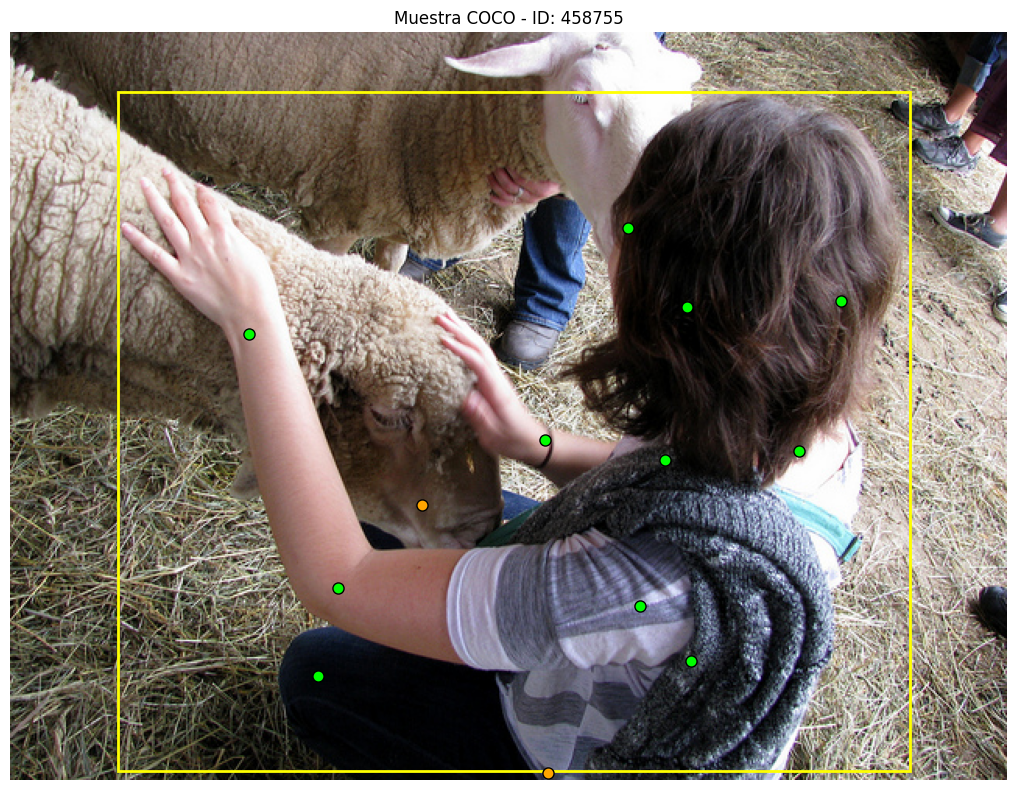

In [124]:
# Cargar una imagen
sample_iterator = iter(loader)

# Saltar las primeras imágenes si es necesario
next(sample_iterator)  # Skip primera

sample = next(sample_iterator)

print(f"\n📸 Muestra cargada:")
print(f"   ID: {sample.image_id}")
print(f"   Shape: {sample.image_array.shape}")
print(f"   BBox: {sample.bbox}")
print(f"   Keypoints: {len(sample.ground_truth_keypoints)}")

# Visualizar imagen con bounding box
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(sample.image_array)

# Dibujar bounding box
x, y, w, h = sample.bbox
rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='yellow', facecolor='none')
ax.add_patch(rect)

# Dibujar ground truth keypoints
for kp in sample.ground_truth_keypoints:
    if kp.confidence > 0:  # Solo keypoints etiquetados
        color = 'lime' if kp.confidence == 1.0 else 'orange'
        ax.plot(kp.x, kp.y, 'o', color=color, markersize=8, markeredgecolor='black', markeredgewidth=1)

ax.set_title(f"Muestra COCO - ID: {sample.image_id}")
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Cargar Modelo HRNet-W32

In [125]:
# Determinar dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🎯 Usando dispositivo: {device}\n")

# Crear adaptador del modelo
model = create_model_adapter(
    model_name="hrnet_w32",
    device=device,
    project_root=PROJECT_ROOT
)

print(f"✅ Modelo HRNet-W32 cargado:")
print(f"   - Model Name: {model.model_name}")
print(f"   - Input Size: {model.input_size}")
print(f"   - Num Keypoints: {model.num_keypoints}")
print(f"   - Device: {model.device}")

INFO:pose_uncertainty.models.adapters:Resolved config: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\models\mmpose\configs\body_2d_keypoint\topdown_heatmap\coco\td-hm_hrnet-w32_8xb64-210e_coco-256x192.py
INFO:pose_uncertainty.models.adapters:Resolved checkpoint: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\models\weights\hrnet_w32.pth


🎯 Usando dispositivo: cpu

Loads checkpoint by local backend from path: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\models\weights\hrnet_w32.pth


INFO:pose_uncertainty.models.adapters:Initialized hrnet-w32 adapter:
  - Input size: (192, 256)
  - Num keypoints: 17
  - Device: cpu


✅ Modelo HRNet-W32 cargado:
   - Model Name: hrnet-w32
   - Input Size: (192, 256)
   - Num Keypoints: 17
   - Device: cpu


## 7. Extraer Heatmaps del Modelo

🔄 Ejecutando inferencia...

✅ Inferencia completada:
   - Heatmap shape: (17, 48, 64)
   - Heatmap range: [0.000, 1.000]
   - Original size: (480, 640)
   - Scale factor: 0.25
   - Model keypoints shape: (17, 2)


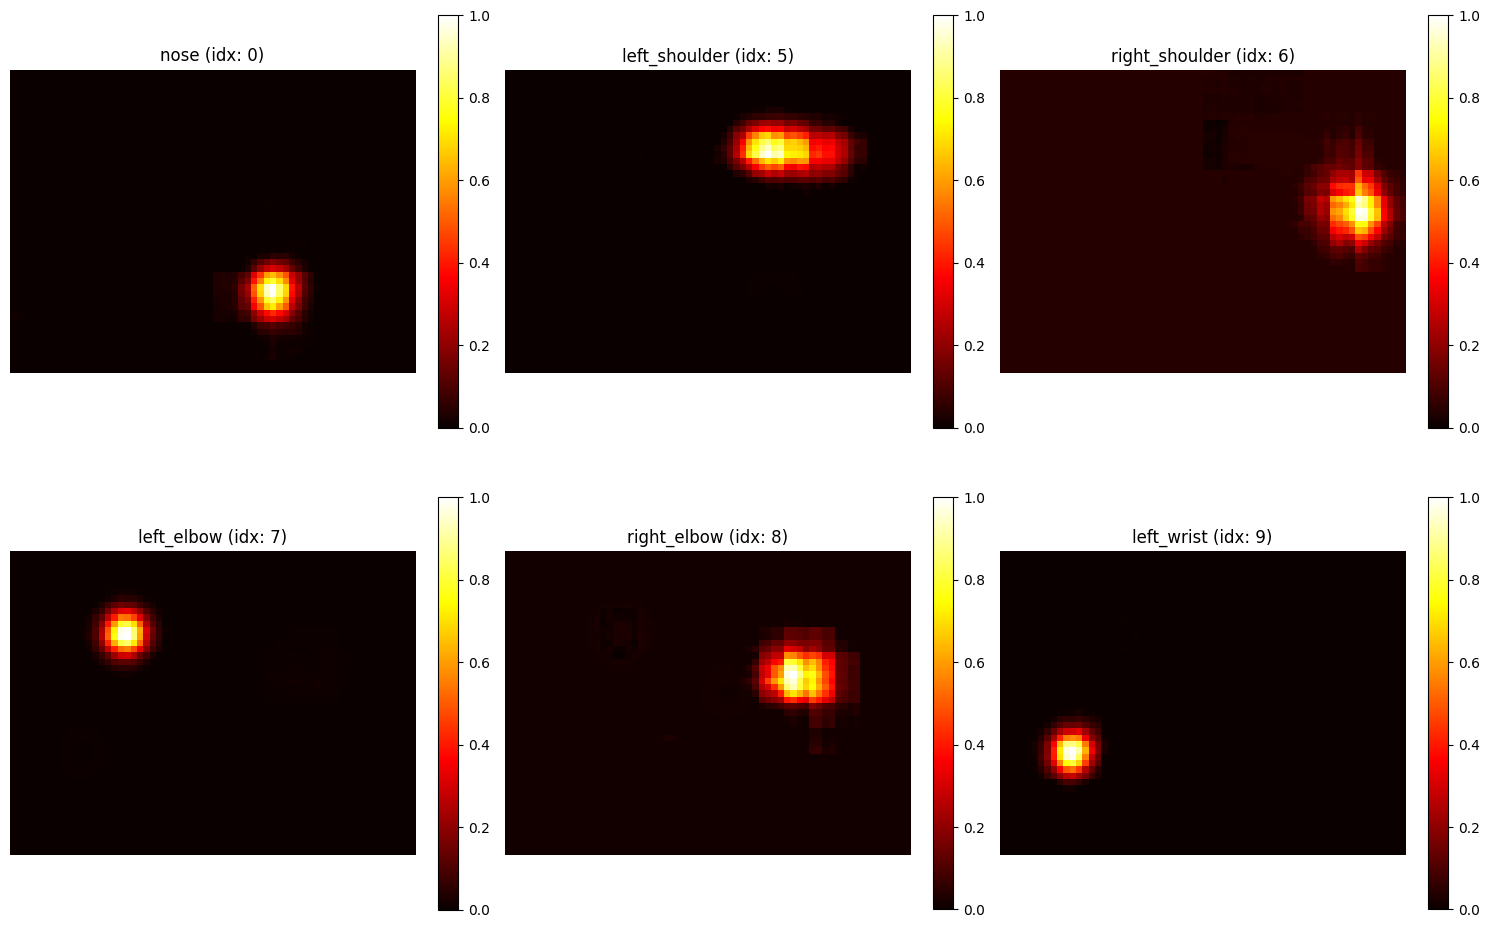

In [126]:
# Ejecutar inferencia
print("🔄 Ejecutando inferencia...")
heatmap_result = model.predict(sample.image_array, bbox=sample.bbox)

# También obtener keypoints predichos por el modelo
model_keypoints, model_scores = model.predict_keypoints(sample.image_array, bbox=sample.bbox)

print(f"\n✅ Inferencia completada:")
print(f"   - Heatmap shape: {heatmap_result.data.shape}")
print(f"   - Heatmap range: [{heatmap_result.data.min():.3f}, {heatmap_result.data.max():.3f}]")
print(f"   - Original size: {heatmap_result.original_size}")
print(f"   - Scale factor: {heatmap_result.scale_factor}")
print(f"   - Model keypoints shape: {model_keypoints.shape}")

# Visualizar algunos heatmaps
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

keypoint_names = ['nose', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist']
for idx, kp_name in enumerate(keypoint_names):
    kp_idx = model.keypoint_names.index(kp_name)
    heatmap = heatmap_result.data[kp_idx]
    
    im = axes[idx].imshow(heatmap, cmap='hot', origin='lower')
    axes[idx].set_title(f"{kp_name} (idx: {kp_idx})")
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx], fraction=0.046)

plt.tight_layout()
plt.show()

## 8. Configurar Sampler con Parámetros del Config

In [127]:
# Crear configuración de sampling desde el YAML
sampling_cfg = SamplingConfig(
    num_samples=int(sampling_config['num_samples']),
    batch_size=int(sampling_config['batch_size']),
    max_iterations=int(sampling_config['max_iterations']),
    use_dequantization=bool(sampling_config['use_dequantization']),
    jitter_magnitude=float(sampling_config['jitter_magnitude']),
    temperature=float(sampling_config['temperature']),
    seed=sampling_config['seed'] if sampling_config['seed'] is not None else None,
    min_heatmap_mass=float(sampling_config.get('min_heatmap_mass', 1e-6))
)

print("✅ Configuración de Sampling:")
print(f"   - Num Samples: {sampling_cfg.num_samples}")
print(f"   - Batch Size: {sampling_cfg.batch_size}")
print(f"   - Method: {sampling_config['method']}")
print(f"   - Use Dequantization: {sampling_cfg.use_dequantization}")

# Crear sampler
sampler = RejectionSampler(config=sampling_cfg)
print(f"\n✅ Sampler creado: {type(sampler).__name__}")

✅ Configuración de Sampling:
   - Num Samples: 5000
   - Batch Size: 50000
   - Method: rejection
   - Use Dequantization: True

✅ Sampler creado: RejectionSampler


## 9. Muestrear de los Heatmaps

In [128]:
# Muestrear de todos los heatmaps
print("🔄 Muestreando de los heatmaps...\n")

all_samples = []  # Lista de samples por keypoint
valid_keypoint_indices = []  # Índices de keypoints válidos

for kp_idx in range(heatmap_result.data.shape[0]):
    heatmap = heatmap_result.data[kp_idx]
    
    try:
        # Usar la función sample_from_heatmap con nuestro sampler
        samples = sampler.sample(heatmap)
        all_samples.append(samples)
        valid_keypoint_indices.append(kp_idx)
        
        print(f"✅ Keypoint {kp_idx} ({model.keypoint_names[kp_idx]}): {len(samples)} samples")
    except Exception as e:
        print(f"⚠️  Keypoint {kp_idx} ({model.keypoint_names[kp_idx]}): Error - {e}")
        all_samples.append(None)

print(f"\n✅ Sampling completado: {len(valid_keypoint_indices)}/{heatmap_result.data.shape[0]} keypoints válidos")

🔄 Muestreando de los heatmaps...

✅ Keypoint 0 (nose): 5000 samples
✅ Keypoint 1 (left_eye): 5000 samples
✅ Keypoint 2 (right_eye): 5000 samples
✅ Keypoint 3 (left_ear): 5000 samples
✅ Keypoint 4 (right_ear): 5000 samples
✅ Keypoint 5 (left_shoulder): 5000 samples
✅ Keypoint 6 (right_shoulder): 5000 samples
✅ Keypoint 7 (left_elbow): 5000 samples
✅ Keypoint 8 (right_elbow): 5000 samples
✅ Keypoint 9 (left_wrist): 5000 samples
✅ Keypoint 10 (right_wrist): 5000 samples
✅ Keypoint 11 (left_hip): 5000 samples
✅ Keypoint 12 (right_hip): 5000 samples
✅ Keypoint 13 (left_knee): 5000 samples
✅ Keypoint 14 (right_knee): 5000 samples
✅ Keypoint 15 (left_ankle): 5000 samples
✅ Keypoint 16 (right_ankle): 5000 samples

✅ Sampling completado: 17/17 keypoints válidos


## 10. Ajustar Modelo de Mixtura con Outer Loop

In [129]:
# Ajustar modelo de mixtura para cada keypoint
print("🔄 Ajustando modelos de mixtura...\n")

mixture_results = []

for kp_idx in valid_keypoint_indices:
    samples = all_samples[kp_idx]
    
    if samples is None or len(samples) == 0:
        mixture_results.append(None)
        continue
    
    try:
        # Ajustar con outer loop usando parámetros del config
        result = fit_with_outer_loop(
            samples=samples,
            n_outer_iterations=int(mixture_config['outer_loop_iterations']),
            n_resamples=int(mixture_config['bootstrap_sample_size']),
            aic_weight=float(mixture_config['aic_weight']),
            bic_weight=float(mixture_config['bic_weight']),
            reg_covar=float(mixture_config['regularization_strength']),
            max_iter=int(mixture_config['max_iterations']),
            tol=float(mixture_config['convergence_threshold']),
            random_state=main_config.get('seed', 42),
            bounding_box = sample.bbox
        )
        
        mixture_results.append(result)
        
        print(f"✅ Keypoint {kp_idx} ({model.keypoint_names[kp_idx]}):")
        print(f"   - Model Type: {result.model_type}")
        print(f"   - Mean: ({result.best_mean[0]:.2f}, {result.best_mean[1]:.2f})")
        print(f"   - Converged: {result.converged}")
        print(f"   - Iterations: {result.n_iterations}")
        
    except Exception as e:
        print(f"⚠️  Keypoint {kp_idx} ({model.keypoint_names[kp_idx]}): Error - {e}")
        mixture_results.append(None)

print(f"\n✅ Mixture fitting completado")

🔄 Ajustando modelos de mixtura...



✅ Keypoint 0 (nose):
   - Model Type: bimodal
   - Mean: (40.82, 12.47)
   - Converged: False
   - Iterations: 370


✅ Keypoint 1 (left_eye):
   - Model Type: unimodal
   - Mean: (41.47, 11.25)
   - Converged: True
   - Iterations: 25
✅ Keypoint 2 (right_eye):
   - Model Type: bimodal
   - Mean: (41.48, 10.62)
   - Converged: True
   - Iterations: 254


✅ Keypoint 3 (left_ear):
   - Model Type: bimodal
   - Mean: (43.75, 14.11)
   - Converged: False
   - Iterations: 308


✅ Keypoint 4 (right_ear):
   - Model Type: unimodal
   - Mean: (58.22, 15.04)
   - Converged: False
   - Iterations: 215


...

✅ Keypoint 10 (right_wrist):
   - Model Type: unimodal
   - Mean: (34.50, 24.98)
   - Converged: True
   - Iterations: 26


✅ Keypoint 11 (left_hip):
   - Model Type: bimodal
   - Mean: (29.90, 45.62)
   - Converged: False
   - Iterations: 421


✅ Keypoint 12 (right_hip):
   - Model Type: bimodal
   - Mean: (33.57, 41.96)
   - Converged: True
   - Iterations: 125


✅ Keypoint 13 (left_knee):
   - Model Type: unimodal
   - Mean: (15.92, 41.14)
   - Converged: True
   - Iterations: 25
✅ Keypoint 14 (right_knee):
   - Model Type: bimodal
   - Mean: (16.12, 41.03)
   - Converged: True
   - Iterations: 61


✅ Keypoint 15 (left_ankle):
   - Model Type: bimodal
   - Mean: (10.33, 10.11)
   - Converged: False
   - Iterations: 318
✅ Keypoint 16 (right_ankle):
   - Model Type: bimodal
   - Mean: (20.97, 45.82)
   - Converged: True
   - Iterations: 31

✅ Mixture fitting completado


## 10.1. Visualización Detallada: Heatmaps, Samples y Gaussianas

Vamos a visualizar para cada keypoint:
- **Heatmap original** del modelo
- **Samples** obtenidos del rejection sampling
- **Gaussiana(s) de la mixtura** ajustadas por el outer loop

In [130]:
from scipy.stats import multivariate_normal

def plot_mixture_components(ax, mixture_result, color='red', alpha=0.3):
    """
    Dibuja las componentes gaussianas de un MixtureResult.
    
    Args:
        ax: Matplotlib axis
        mixture_result: MixtureResult con componentes gaussianas
        color: Color para las elipses
        alpha: Transparencia
    """
    if mixture_result is None or mixture_result.components is None:
        return
    
    for comp in mixture_result.components:
        mean = comp.mean
        cov = comp.covariance
        weight = comp.weight
        
        # Calcular eigenvalues para la elipse
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        
        # 2 sigma ellipse
        width, height = 2 * np.sqrt(eigenvalues) * 2
        
        ellipse = Ellipse(
            (mean[0], mean[1]), 
            width, 
            height, 
            angle=angle,
            facecolor=color,
            edgecolor=color,
            linewidth=2,
            alpha=alpha * weight,  # Escalar alpha por el peso
            label=f'w={weight:.2f}'
        )
        ax.add_patch(ellipse)
        
        # Dibujar el centro
        ax.plot(mean[0], mean[1], 'x', color=color, markersize=10, markeredgewidth=3)


def visualize_keypoint_analysis(kp_idx, heatmap, samples, mixture_result, kp_name):
    """
    Visualiza el análisis completo de un keypoint: heatmap, samples y mixtura.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Heatmap original
    im1 = axes[0].imshow(heatmap, cmap='hot', origin='lower', interpolation='bilinear')
    axes[0].set_title(f'{kp_name}\\nHeatmap Original', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('X (pixels)')
    axes[0].set_ylabel('Y (pixels)')
    plt.colorbar(im1, ax=axes[0], fraction=0.046)
    
    # 2. Heatmap con samples
    axes[1].imshow(heatmap, cmap='hot', origin='lower', alpha=0.6, interpolation='bilinear')
    if samples is not None and len(samples) > 0:
        axes[1].scatter(samples[:, 0], samples[:, 1], 
                       c='cyan', s=1, alpha=0.3, label=f'{len(samples)} samples')
    axes[1].set_title(f'{kp_name}\\nSampling (Rejection)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('X (pixels)')
    axes[1].set_ylabel('Y (pixels)')
    axes[1].legend(loc='upper right')
    
    # 3. Samples con gaussianas de la mixtura
    if samples is not None and len(samples) > 0:
        axes[2].scatter(samples[:, 0], samples[:, 1], 
                       c='lightblue', s=2, alpha=0.2, label='Samples')
    
    if mixture_result is not None:
        # Dibujar componentes gaussianas
        plot_mixture_components(axes[2], mixture_result, color='red', alpha=0.3)
        
        # Dibujar el mejor estimado (mean agregado del outer loop)
        axes[2].plot(mixture_result.best_mean[0], mixture_result.best_mean[1], 
                    markeredgewidth=2, label='Best Mean', zorder=10)
        
        # Dibujar elipse de covarianza del best estimate
        eigenvalues, eigenvectors = np.linalg.eig(mixture_result.best_covariance)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * np.sqrt(eigenvalues) * 2
        
        ellipse = Ellipse(
            (mixture_result.best_mean[0], mixture_result.best_mean[1]),
            width, height, angle=angle,
            facecolor='none', edgecolor='green', linewidth=3,
            linestyle='--', label='Best Covariance (2σ)'
        )
        axes[2].add_patch(ellipse)
    
    axes[2].set_title(f'{kp_name}\\nMixtura Outer Loop ({mixture_result.model_type if mixture_result else "N/A"})', 
                     fontsize=12, fontweight='bold')
    axes[2].set_xlabel('X (pixels)')
    axes[2].set_ylabel('Y (pixels)')
    axes[2].legend(loc='upper right', fontsize=8)
    
    # Mantener mismos límites en todos los plots
    xlim = axes[1].get_xlim()
    ylim = axes[1].get_ylim()
    for ax in axes:
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

print("✅ Funciones de visualización definidas")

✅ Funciones de visualización definidas


### 10.1.1. Visualizar Keypoints Seleccionados

Visualizaremos algunos keypoints representativos para ver el proceso completo.

In [131]:
# Seleccionar keypoints interesantes para visualizar
keypoints_to_visualize = [
    'nose',
    'left_shoulder', 
    'right_shoulder',
    'left_elbow',
    'right_wrist',
    'left_hip'
]

# Encontrar índices de estos keypoints
kp_indices_to_viz = []
for kp_name in keypoints_to_visualize:
    if kp_name in model.keypoint_names:
        kp_idx = model.keypoint_names.index(kp_name)
        if kp_idx in valid_keypoint_indices:
            kp_indices_to_viz.append(kp_idx)

print(f"Visualizando {len(kp_indices_to_viz)} keypoints: {[model.keypoint_names[i] for i in kp_indices_to_viz]}")

Visualizando 6 keypoints: ['nose', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_wrist', 'left_hip']


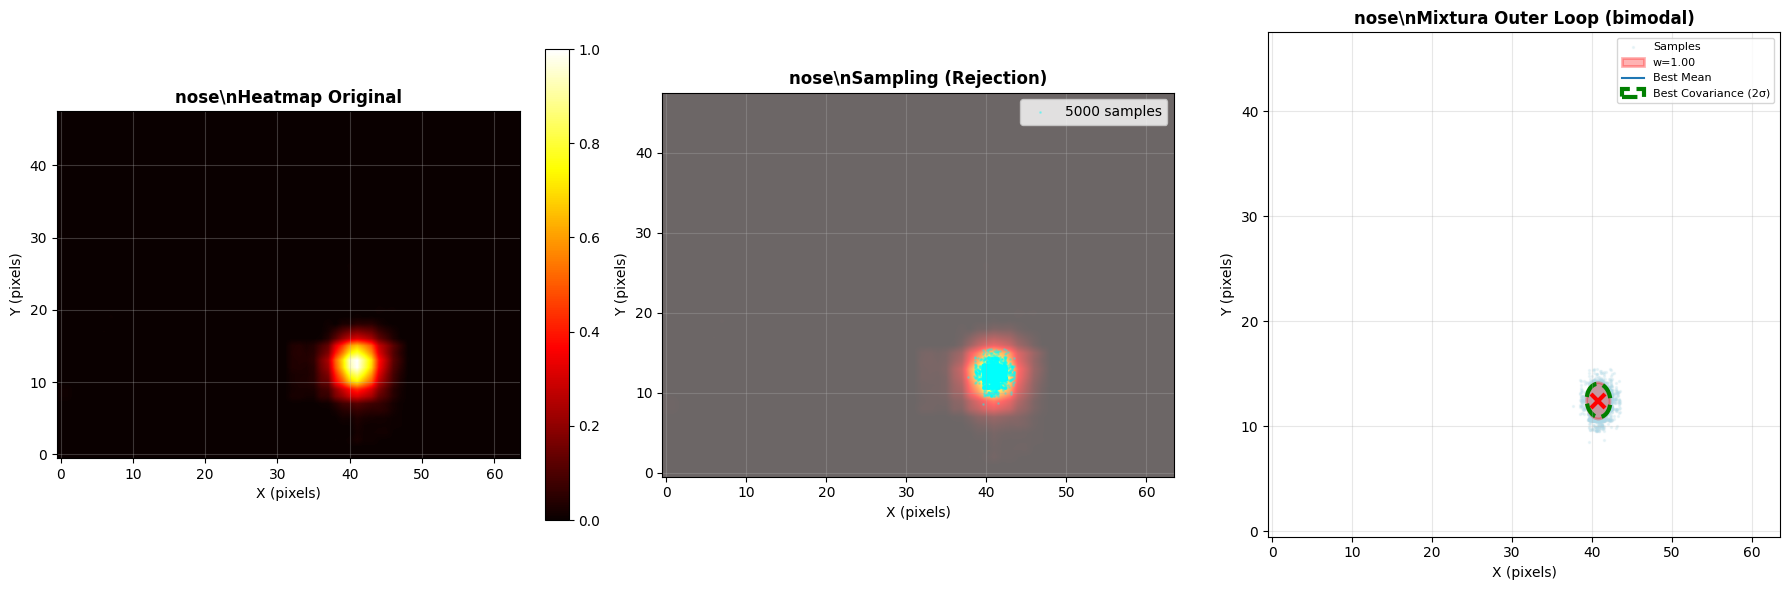


nose - Estadísticas:
  Model Type: bimodal
  Best Mean: (40.82, 12.47)
  Num Components: 1
  Converged: False
  Log-Likelihood: -2372.96
  AIC: 4757.92, BIC: 4787.37

  Componentes:
    [0] Weight: 1.000, Mean: (40.79, 12.43)




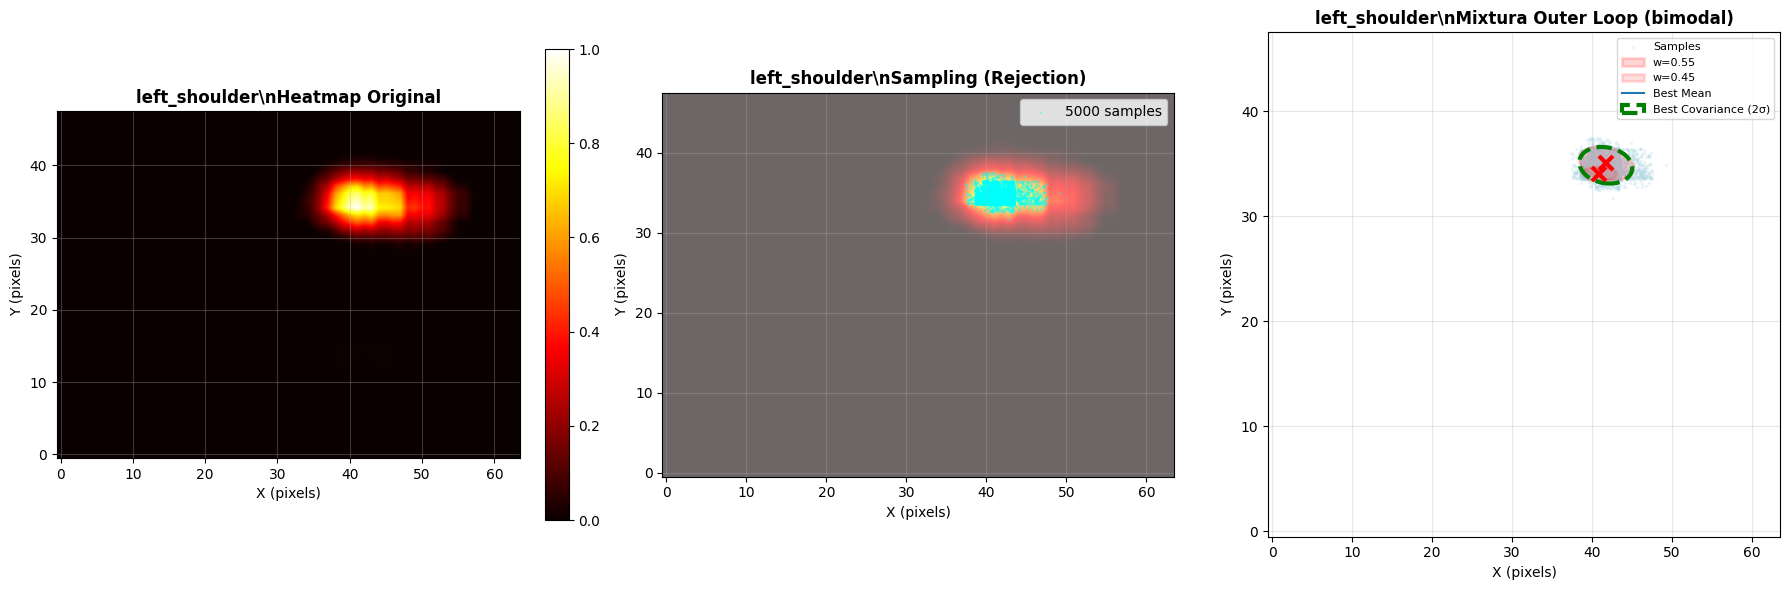


left_shoulder - Estadísticas:
  Model Type: bimodal
  Best Mean: (41.72, 34.85)
  Num Components: 2
  Converged: False
  Log-Likelihood: -2927.01
  AIC: 5878.02, BIC: 5936.91

  Componentes:
    [0] Weight: 0.553, Mean: (41.80, 35.03)
    [1] Weight: 0.447, Mean: (40.92, 34.02)




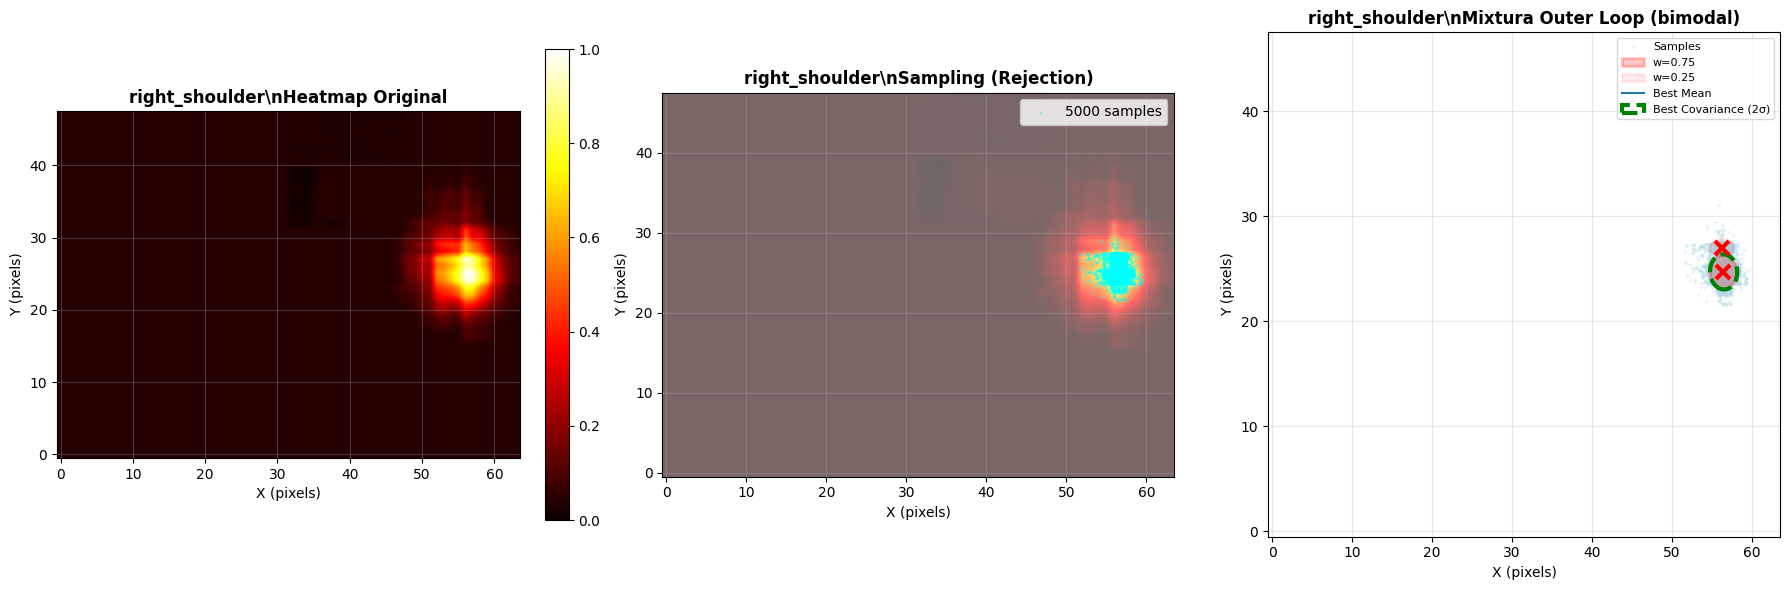


right_shoulder - Estadísticas:
  Model Type: bimodal
  Best Mean: (56.45, 24.70)
  Num Components: 2
  Converged: True
  Log-Likelihood: -2746.02
  AIC: 5516.03, BIC: 5574.93

  Componentes:
    [0] Weight: 0.749, Mean: (56.42, 24.70)
    [1] Weight: 0.251, Mean: (56.22, 27.00)




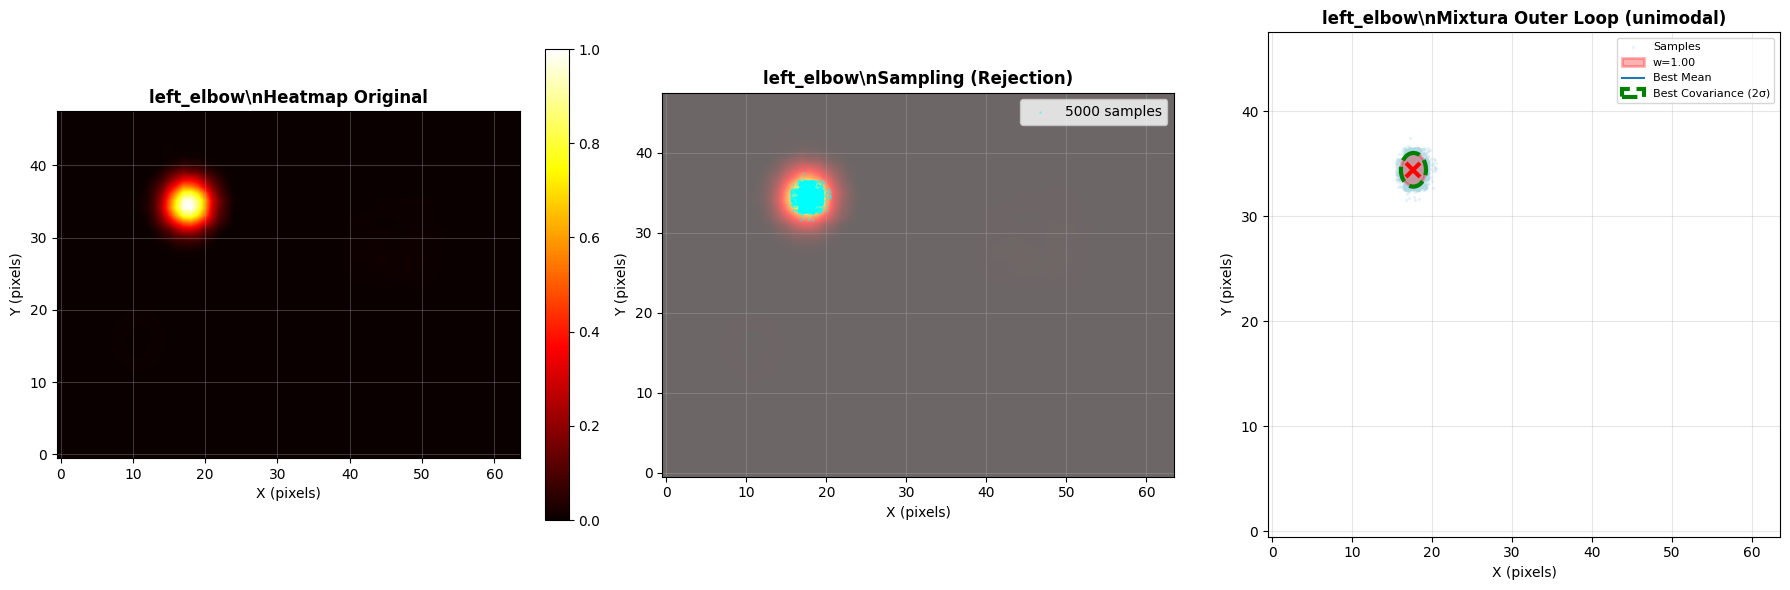


left_elbow - Estadísticas:
  Model Type: unimodal
  Best Mean: (17.67, 34.42)
  Num Components: 1
  Converged: True
  Log-Likelihood: -2328.37
  AIC: 4668.75, BIC: 4698.19

  Componentes:
    [0] Weight: 1.000, Mean: (17.68, 34.43)




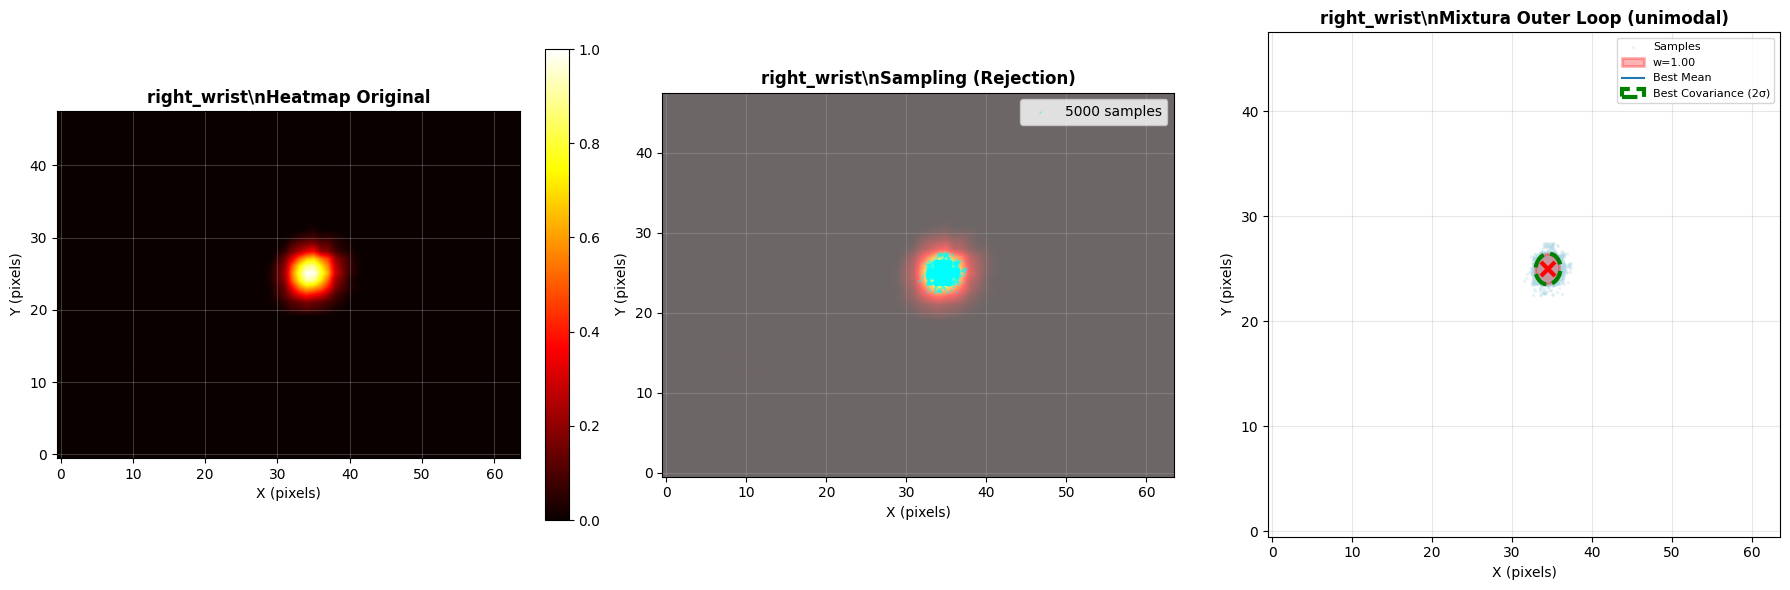


right_wrist - Estadísticas:
  Model Type: unimodal
  Best Mean: (34.50, 24.98)
  Num Components: 1
  Converged: True
  Log-Likelihood: -2218.36
  AIC: 4448.73, BIC: 4478.17

  Componentes:
    [0] Weight: 1.000, Mean: (34.45, 24.96)




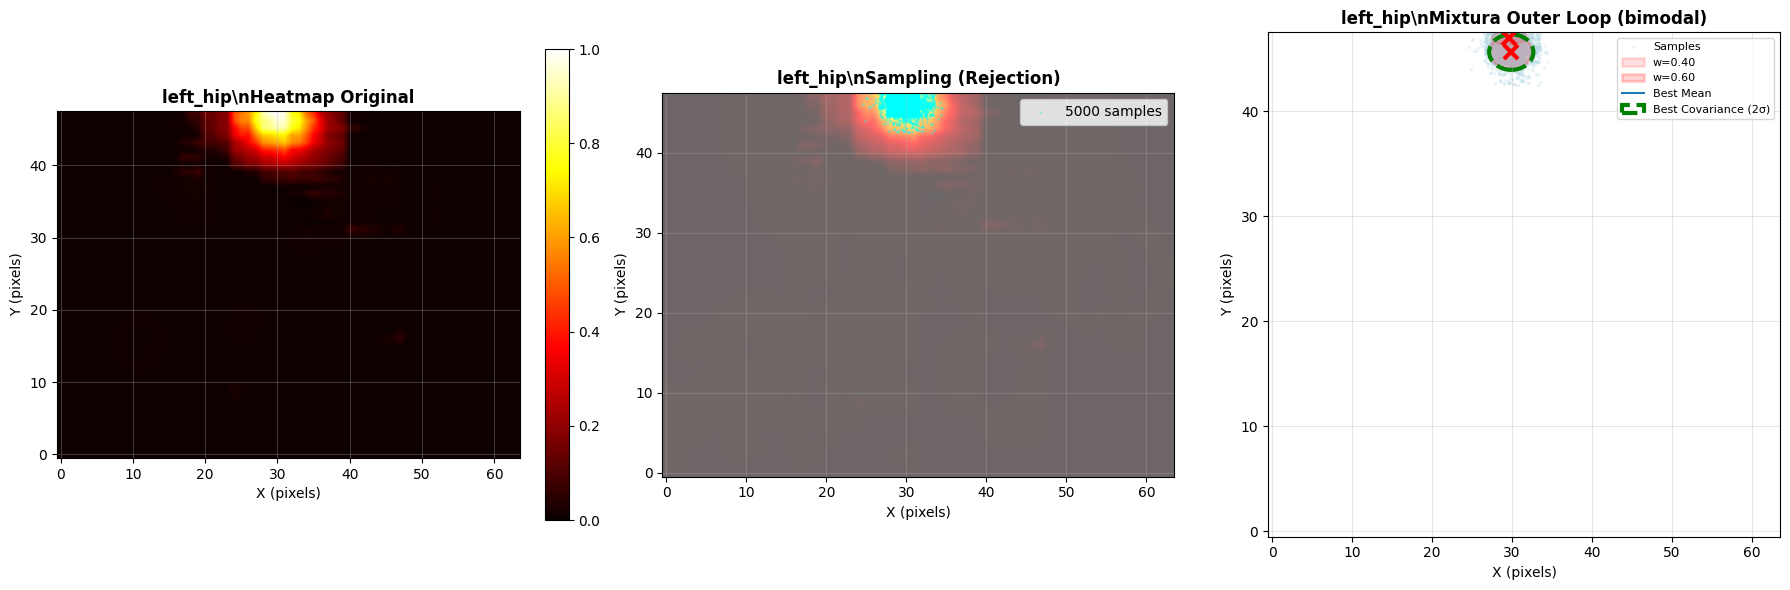


left_hip - Estadísticas:
  Model Type: bimodal
  Best Mean: (29.90, 45.62)
  Num Components: 2
  Converged: False
  Log-Likelihood: -2909.64
  AIC: 5843.27, BIC: 5902.16

  Componentes:
    [0] Weight: 0.401, Mean: (29.68, 47.00)
    [1] Weight: 0.599, Mean: (29.85, 45.64)




In [132]:
# Visualizar cada keypoint seleccionado
for kp_idx in kp_indices_to_viz:
    kp_name = model.keypoint_names[kp_idx]
    heatmap = heatmap_result.data[kp_idx]
    samples = all_samples[kp_idx]
    
    # Encontrar el índice en mixture_results
    if kp_idx in valid_keypoint_indices:
        result_idx = valid_keypoint_indices.index(kp_idx)
        mixture_result = mixture_results[result_idx]
    else:
        mixture_result = None
    
    fig = visualize_keypoint_analysis(kp_idx, heatmap, samples, mixture_result, kp_name)
    plt.show()
    
    # Imprimir estadísticas
    if mixture_result is not None:
        print(f"\n{kp_name} - Estadísticas:")
        print(f"  Model Type: {mixture_result.model_type}")
        print(f"  Best Mean: ({mixture_result.best_mean[0]:.2f}, {mixture_result.best_mean[1]:.2f})")
        print(f"  Num Components: {len(mixture_result.components) if mixture_result.components else 0}")
        print(f"  Converged: {mixture_result.converged}")
        print(f"  Log-Likelihood: {mixture_result.log_likelihood:.2f}")
        print(f"  AIC: {mixture_result.aic:.2f}, BIC: {mixture_result.bic:.2f}")
        if mixture_result.components:
            print(f"\n  Componentes:")
            for i, comp in enumerate(mixture_result.components):
                print(f"    [{i}] Weight: {comp.weight:.3f}, Mean: ({comp.mean[0]:.2f}, {comp.mean[1]:.2f})")
    
    print("\n" + "="*80 + "\n")

### 10.1.2. Visualización Compacta de Todos los Keypoints

Grid de todos los keypoints procesados.

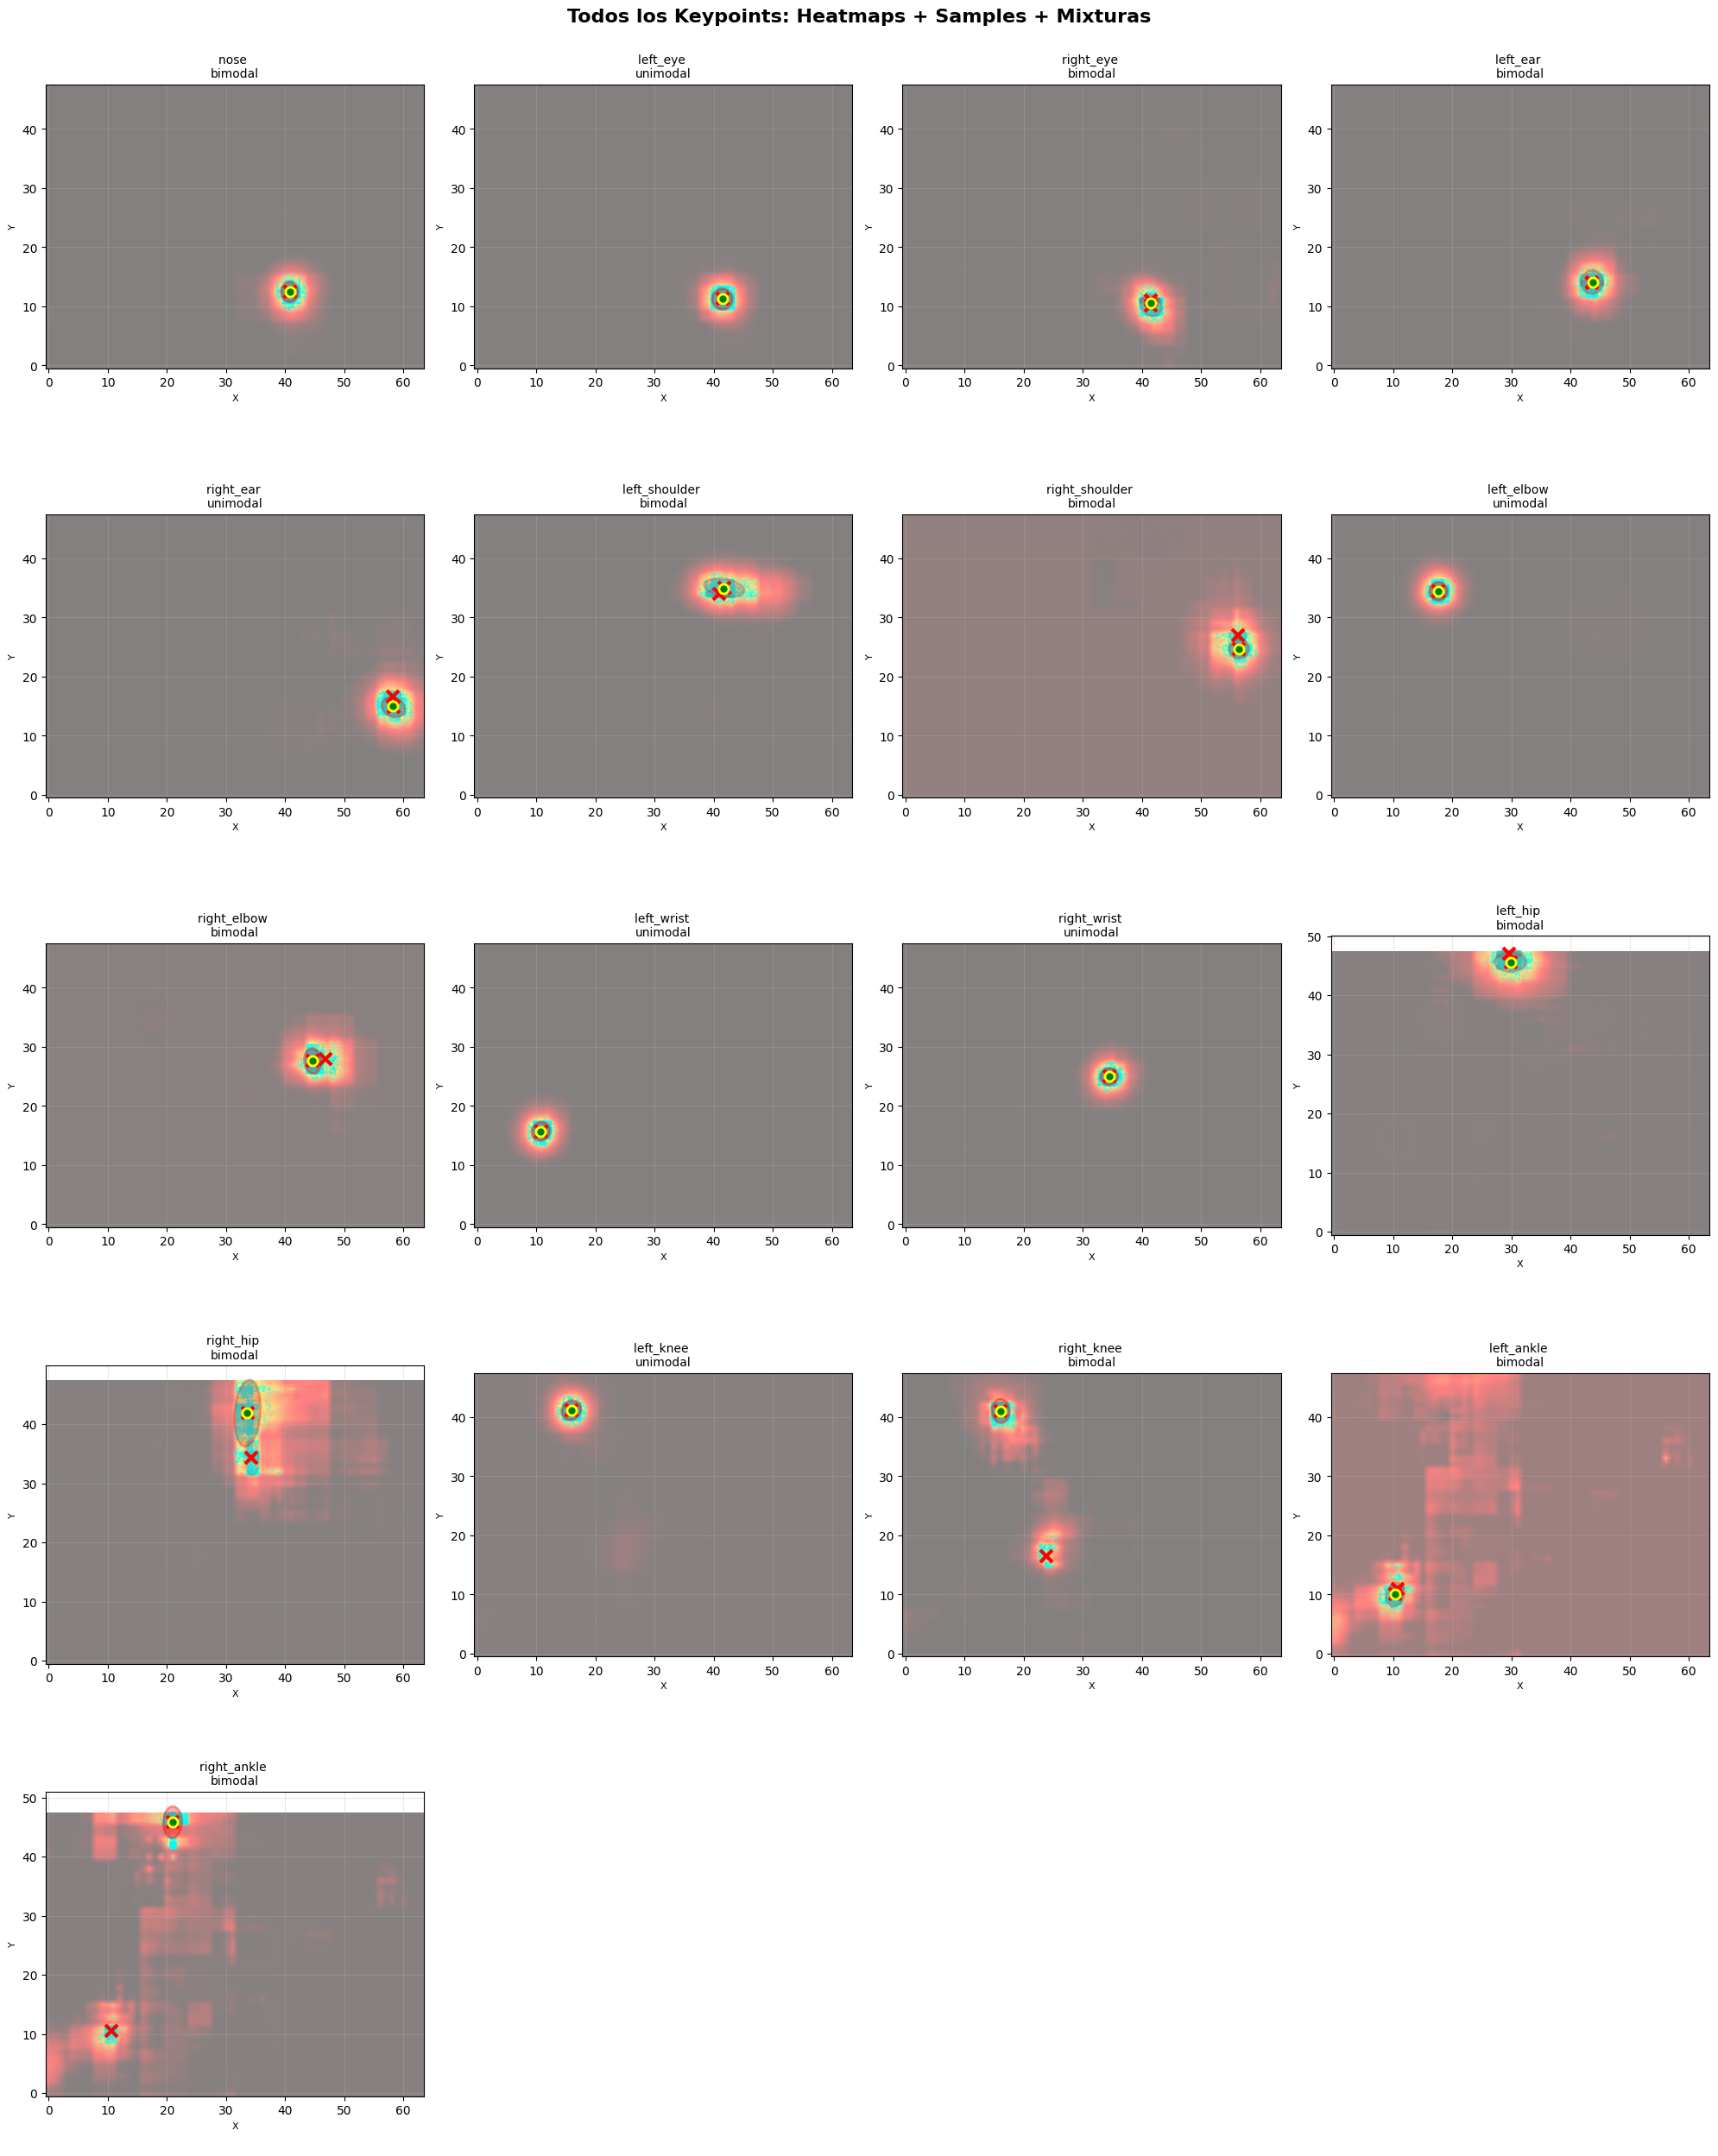

In [133]:
# Crear un grid con todos los keypoints válidos
n_keypoints = len(valid_keypoint_indices)
n_cols = 4
n_rows = int(np.ceil(n_keypoints / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() if n_keypoints > 1 else [axes]

for plot_idx, kp_idx in enumerate(valid_keypoint_indices):
    ax = axes[plot_idx]
    kp_name = model.keypoint_names[kp_idx]
    
    heatmap = heatmap_result.data[kp_idx]
    samples = all_samples[kp_idx]
    result_idx = valid_keypoint_indices.index(kp_idx)
    mixture_result = mixture_results[result_idx]
    
    # Dibujar heatmap de fondo
    ax.imshow(heatmap, cmap='hot', origin='lower', alpha=0.5, interpolation='bilinear')
    
    # Dibujar samples
    if samples is not None and len(samples) > 0:
        ax.scatter(samples[:, 0], samples[:, 1], c='cyan', s=0.5, alpha=0.2)
    
    # Dibujar gaussianas de la mixtura
    if mixture_result is not None:
        plot_mixture_components(ax, mixture_result, color='red', alpha=0.4)
        
        # Dibujar best mean
        ax.plot(mixture_result.best_mean[0], mixture_result.best_mean[1],
               'go', markersize=8, markeredgecolor='yellow', markeredgewidth=2)
        
        # Título con info
        title = f"{kp_name} \n{mixture_result.model_type}"
    else:
        title = f"{kp_name}\nNo fit"
    
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X', fontsize=8)
    ax.set_ylabel('Y', fontsize=8)
    ax.grid(True, alpha=0.3)

# Ocultar ejes sobrantes
for idx in range(n_keypoints, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Todos los Keypoints: Heatmaps + Samples + Mixturas', 
             fontsize=16, fontweight='bold', y=1.001)
plt.show()

## 11. Reescalar Keypoints de la Mixtura a Coordenadas Originales

In [134]:
# Reescalar keypoints de heatmap space a image space
print("🔄 Reescalando keypoints...\n")

mixture_keypoints = np.zeros((len(valid_keypoint_indices), 2))

for idx, kp_idx in enumerate(valid_keypoint_indices):
    result = mixture_results[idx]
    
    if result is None:
        continue
    
    # Coordenadas en heatmap space
    heatmap_x, heatmap_y = result.best_mean
    
    # Reescalar a coordenadas de imagen original
    # Usar la información de StandardizedHeatmap para hacer el transform inverso
    scale_x = heatmap_result.original_size[1] / heatmap_result.data.shape[2]  # width
    scale_y = heatmap_result.original_size[0] / heatmap_result.data.shape[1]  # height
    
    # Aplicar offset del bbox si existe
    bbox_x, bbox_y, bbox_w, bbox_h = sample.bbox
    
    # Transformar de heatmap space a bbox space
    bbox_space_x = heatmap_x * scale_x
    bbox_space_y = heatmap_y * scale_y
    
    # Transformar de bbox space a image space
    image_x = bbox_x + bbox_space_x
    image_y = bbox_y + bbox_space_y
    
    mixture_keypoints[idx] = [image_x, image_y]
    
    print(f"Keypoint {kp_idx} ({model.keypoint_names[kp_idx]}):")
    print(f"   Heatmap: ({heatmap_x:.2f}, {heatmap_y:.2f})")
    print(f"   Image:   ({image_x:.2f}, {image_y:.2f})")

print(f"\n✅ Reescalado completado")

🔄 Reescalando keypoints...

Keypoint 0 (nose):
   Heatmap: (40.82, 12.47)
   Image:   (477.18, 162.45)
Keypoint 1 (left_eye):
   Heatmap: (41.47, 11.25)
   Image:   (483.69, 150.26)
Keypoint 2 (right_eye):
   Heatmap: (41.48, 10.62)
   Image:   (483.79, 143.92)
Keypoint 3 (left_ear):
   Heatmap: (43.75, 14.11)
   Image:   (506.50, 178.84)
Keypoint 4 (right_ear):
   Heatmap: (58.22, 15.04)
   Image:   (651.26, 188.17)
Keypoint 5 (left_shoulder):
   Heatmap: (41.72, 34.85)
   Image:   (486.21, 386.26)
Keypoint 6 (right_shoulder):
   Heatmap: (56.45, 24.70)
   Image:   (633.57, 284.80)
Keypoint 7 (left_elbow):
   Heatmap: (17.67, 34.42)
   Image:   (245.77, 381.92)
Keypoint 8 (right_elbow):
   Heatmap: (44.66, 27.70)
   Image:   (515.60, 314.70)
Keypoint 9 (left_wrist):
   Heatmap: (10.78, 15.72)
   Image:   (176.83, 194.97)
Keypoint 10 (right_wrist):
   Heatmap: (34.50, 24.98)
   Image:   (414.07, 287.52)
Keypoint 11 (left_hip):
   Heatmap: (29.90, 45.62)
   Image:   (368.06, 493.95)
Key

In [135]:
# Comparar resultados de la celda 31 (final_keypoints) con los de la celda 30 (mixture_keypoints)
print("📊 Comparando resultados de la celda 31 (puntos con mayor probabilidad) con la celda 30 (mixtura)...\n")

# Asegurarse de que ambas listas tengan el mismo número de keypoints
if len(final_keypoints) != len(mixture_keypoints):
    print("⚠️  El número de keypoints no coincide entre las dos celdas.")
else:
    # Calcular diferencias
    differences = []
    for idx, (max_prob, mixture) in enumerate(zip(final_keypoints, mixture_keypoints)):
        diff = np.linalg.norm(np.array(max_prob) - np.array(mixture))
        differences.append(diff)
        print(f"Keypoint {idx} ({model.keypoint_names[idx]}):")
        print(f"   Celda 31 (Max Prob): ({max_prob[0]:.2f}, {max_prob[1]:.2f})")
        print(f"   Celda 30 (Mixtura): ({mixture[0]:.2f}, {mixture[1]:.2f})")
        print(f"   Diferencia: {diff:.2f} px\n")
    
    # Resumen de diferencias
    print("=== Resumen de Diferencias ===")
    print(f"Promedio: {np.mean(differences):.2f} px")
    print(f"Desviación Estándar: {np.std(differences):.2f} px")
    print(f"Máxima Diferencia: {np.max(differences):.2f} px")
    print(f"Mínima Diferencia: {np.min(differences):.2f} px")

📊 Comparando resultados de la celda 31 (puntos con mayor probabilidad) con la celda 30 (mixtura)...

Keypoint 0 (nose):
   Celda 31 (Max Prob): (232.03, 88.75)
   Celda 30 (Mixtura): (477.18, 162.45)
   Diferencia: 255.99 px

Keypoint 1 (left_eye):
   Celda 31 (Max Prob): (234.03, 82.75)
   Celda 30 (Mixtura): (483.69, 150.26)
   Diferencia: 258.63 px

Keypoint 2 (right_eye):
   Celda 31 (Max Prob): (236.03, 80.75)
   Celda 30 (Mixtura): (483.79, 143.92)
   Diferencia: 255.69 px

Keypoint 3 (left_ear):
   Celda 31 (Max Prob): (244.03, 94.75)
   Celda 30 (Mixtura): (506.50, 178.84)
   Diferencia: 275.61 px

Keypoint 4 (right_ear):
   Celda 31 (Max Prob): (302.03, 96.75)
   Celda 30 (Mixtura): (651.26, 188.17)
   Diferencia: 361.00 px

Keypoint 5 (left_shoulder):
   Celda 31 (Max Prob): (232.03, 174.75)
   Celda 30 (Mixtura): (486.21, 386.26)
   Diferencia: 330.67 px

Keypoint 6 (right_shoulder):
   Celda 31 (Max Prob): (294.03, 136.75)
   Celda 30 (Mixtura): (633.57, 284.80)
   Diferenc

## 12. Comparar Resultados: Ground Truth vs Modelo vs Mixtura

In [136]:
# Preparar datos para visualización
print("📊 Comparando resultados...\n")

# Ground Truth
gt_keypoints = np.array([[kp.x, kp.y] for kp in sample.ground_truth_keypoints])
gt_confidence = np.array([kp.confidence for kp in sample.ground_truth_keypoints])

# Modelo (predicciones directas)
# model_keypoints ya está en coordenadas de imagen

# Calcular errores (solo para keypoints visibles)
errors_model = []
errors_mixture = []

for idx, kp_idx in enumerate(valid_keypoint_indices):
    if gt_confidence[kp_idx] > 0:  # Solo keypoints etiquetados
        gt = gt_keypoints[kp_idx]
        
        # Error del modelo
        model_pred = model_keypoints[kp_idx]
        error_model = np.linalg.norm(gt - model_pred)
        errors_model.append(error_model)
        
        # Error de la mixtura
        if mixture_results[idx] is not None:
            mixture_pred = mixture_keypoints[idx]
            error_mixture = np.linalg.norm(gt - mixture_pred)
            errors_mixture.append(error_mixture)

print(f"=== Errores (Euclidean Distance) ===")
print(f"Modelo:")
print(f"   Mean: {np.mean(errors_model):.2f} pixels")
print(f"   Std:  {np.std(errors_model):.2f} pixels")
print(f"   Max:  {np.max(errors_model):.2f} pixels")
print(f"\nMixtura:")
print(f"   Mean: {np.mean(errors_mixture):.2f} pixels")
print(f"   Std:  {np.std(errors_mixture):.2f} pixels")
print(f"   Max:  {np.max(errors_mixture):.2f} pixels")

📊 Comparando resultados...

=== Errores (Euclidean Distance) ===
Modelo:
   Mean: 31.68 pixels
   Std:  36.40 pixels
   Max:  125.28 pixels

Mixtura:
   Mean: 82.56 pixels
   Std:  34.23 pixels
   Max:  148.91 pixels


## 13. Visualización Final: Comparación Visual

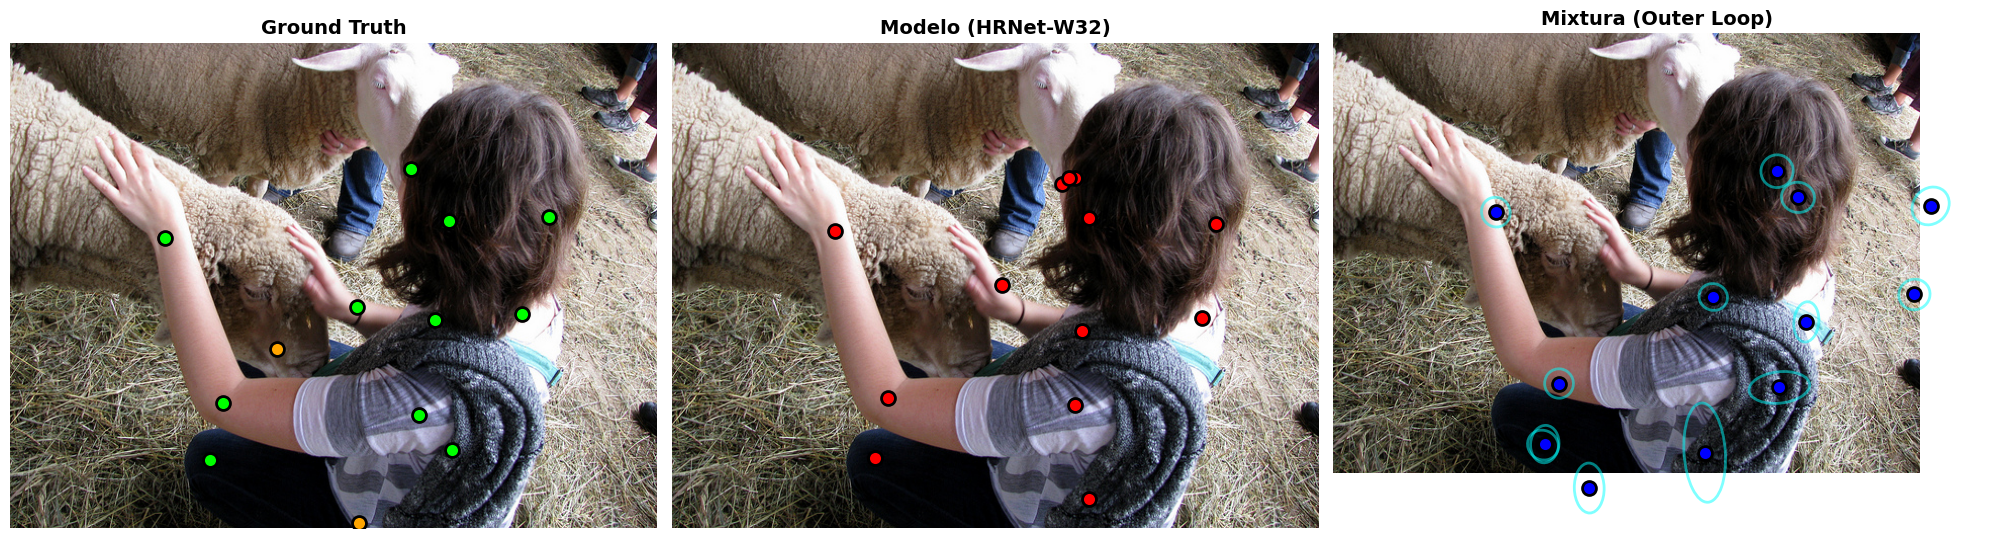

In [137]:
# Visualizar resultados
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Ground Truth
axes[0].imshow(sample.image_array)
for kp in sample.ground_truth_keypoints:
    if kp.confidence > 0:
        color = 'lime' if kp.confidence == 1.0 else 'orange'
        axes[0].plot(kp.x, kp.y, 'o', color=color, markersize=10, 
                     markeredgecolor='black', markeredgewidth=2)
axes[0].set_title("Ground Truth", fontsize=14, fontweight='bold')
axes[0].axis('off')

# Modelo
axes[1].imshow(sample.image_array)
for kp_idx, (x, y) in enumerate(model_keypoints):
    if model_scores[kp_idx] > 0.3:  # Umbral de confianza
        axes[1].plot(x, y, 'o', color='red', markersize=10, 
                     markeredgecolor='black', markeredgewidth=2)
axes[1].set_title("Modelo (HRNet-W32)", fontsize=14, fontweight='bold')
axes[1].axis('off')

# Mixtura
axes[2].imshow(sample.image_array)
for idx, kp_idx in enumerate(valid_keypoint_indices):
    if mixture_results[idx] is not None and gt_confidence[kp_idx] > 0:
        x, y = mixture_keypoints[idx]
        axes[2].plot(x, y, 'o', color='blue', markersize=10, 
                     markeredgecolor='black', markeredgewidth=2)
        
        # Dibujar elipse de covarianza (opcional)
        cov = mixture_results[idx].best_covariance
        
        # Reescalar covarianza
        scale_x = heatmap_result.original_size[1] / heatmap_result.data.shape[2]
        scale_y = heatmap_result.original_size[0] / heatmap_result.data.shape[1]
        cov_scaled = cov.copy()
        cov_scaled[0, 0] *= scale_x**2
        cov_scaled[1, 1] *= scale_y**2
        cov_scaled[0, 1] *= scale_x * scale_y
        cov_scaled[1, 0] *= scale_x * scale_y
        
        # Calcular eigenvalues para la elipse
        eigenvalues, eigenvectors = np.linalg.eig(cov_scaled)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * np.sqrt(eigenvalues) * 2  # 2 sigma
        
        ellipse = Ellipse((x, y), width, height, angle=angle,
                         facecolor='none', edgecolor='cyan', linewidth=2, alpha=0.5)
        axes[2].add_patch(ellipse)

axes[2].set_title("Mixtura (Outer Loop)", fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 14. Análisis Detallado por Keypoint

In [144]:
# Tabla comparativa
print("=" * 100)
print(f"{'Keypoint':<20} {'GT (x, y)':<20} {'Model (x, y)':<20} {'Mixture (x, y)':<20} {'Error Model':<15} {'Error Mix':<15}")
print("=" * 100)

for idx, kp_idx in enumerate(valid_keypoint_indices):
    if gt_confidence[kp_idx] > 0 and mixture_results[idx] is not None:
        kp_name = model.keypoint_names[kp_idx]
        
        gt = gt_keypoints[kp_idx]
        model_pred = model_keypoints[kp_idx]
        mixture_pred = mixture_keypoints[idx]
        
        error_model = np.linalg.norm(gt - model_pred)
        error_mixture = np.linalg.norm(gt - mixture_pred)
        
        print(f"{kp_name:<20} ({gt[0]:>5.1f}, {gt[1]:>5.1f})  "
              f"({model_pred[0]:>5.1f}, {model_pred[1]:>5.1f})  "
              f"({mixture_pred[0]:>5.1f}, {mixture_pred[1]:>5.1f})  "
              f"{error_model:>8.2f} px     {error_mixture:>8.2f} px")

print("=" * 100)

Keypoint             GT (x, y)            Model (x, y)         Mixture (x, y)       Error Model     Error Mix      
left_eye             (396.0, 125.0)  (399.1, 133.3)  (483.7, 150.3)      8.83 px        91.26 px
left_ear             (434.0, 176.0)  (412.4, 172.9)  (506.5, 178.8)     21.85 px        72.56 px
right_ear            (533.0, 172.0)  (538.1, 179.6)  (651.3, 188.2)      9.10 px       119.36 px
left_shoulder        (404.0, 368.0)  (399.1, 358.2)  (486.2, 386.3)     10.96 px        84.22 px
right_shoulder       (506.0, 268.0)  (524.8, 272.2)  (633.6, 284.8)     19.28 px       128.67 px
left_elbow           (210.0, 356.0)  (213.9, 351.6)  (245.8, 381.9)      5.91 px        44.17 px
right_elbow          (420.0, 274.0)  (405.7, 285.4)  (515.6, 314.7)     18.26 px       103.91 px
left_wrist           (153.0, 193.0)  (161.0, 186.2)  (176.8, 195.0)     10.50 px        23.92 px
right_wrist          (343.0, 261.0)  (326.4, 239.1)  (414.1, 287.5)     27.50 px        75.85 px
right_hip  

## 15. Comparar Resultados: Máxima Probabilidad Heatmap + Mixtura

In [139]:
# Comparar puntos de máxima probabilidad del heatmap con los puntos de mixture_results
print("📊 Comparando puntos de máxima probabilidad del heatmap con los puntos de mixture_results...\n")

# Asegurarse de que las dimensiones coincidan
if len(mixture_results) != heatmap_result.data.shape[0]:
    print("⚠️  El número de keypoints en mixture_results no coincide con los heatmaps.")
else:
    differences = []
    for kp_idx in range(len(mixture_results)):
        # Obtener el punto de máxima probabilidad del heatmap
        heatmap = heatmap_result.data[np.newaxis, :]  # Agregar dimensión de batch
        preds, _ = get_max_preds(heatmap)
        max_prob_point = preds[0, kp_idx]  # Coordenadas (x, y) del heatmap

        # Obtener el punto de mixture_results
        mixture_result = mixture_results[kp_idx]
        if mixture_result is None:
            print(f"Keypoint {kp_idx} ({model.keypoint_names[kp_idx]}): No se pudo ajustar mixture_results.")
            continue
        mixture_point = mixture_result.best_mean  # Coordenadas (x, y) de mixture_results

        # Calcular la diferencia entre ambos puntos
        diff = np.linalg.norm(max_prob_point - mixture_point)
        differences.append(diff)

        # Imprimir resultados
        print(f"Keypoint {kp_idx} ({model.keypoint_names[kp_idx]}):")
        print(f"   Heatmap Max Prob: ({max_prob_point[0]:.2f}, {max_prob_point[1]:.2f})")
        print(f"   Mixture Result:  ({mixture_point[0]:.2f}, {mixture_point[1]:.2f})")
        print(f"   Diferencia: {diff:.2f} px\n")

    # Resumen de diferencias
    print("=== Resumen de Diferencias ===")
    print(f"Promedio: {np.mean(differences):.2f} px")
    print(f"Desviación Estándar: {np.std(differences):.2f} px")
    print(f"Mínima Diferencia: {np.min(differences):.2f} px")
    print(f"Máxima Diferencia: {np.max(differences):.2f} px")

📊 Comparando puntos de máxima probabilidad del heatmap con los puntos de mixture_results...

Keypoint 0 (nose):
   Heatmap Max Prob: (41.00, 13.00)
   Mixture Result:  (40.82, 12.47)
   Diferencia: 0.56 px

Keypoint 1 (left_eye):
   Heatmap Max Prob: (41.00, 11.00)
   Mixture Result:  (41.47, 11.25)
   Diferencia: 0.53 px

Keypoint 2 (right_eye):
   Heatmap Max Prob: (42.00, 11.00)
   Mixture Result:  (41.48, 10.62)
   Diferencia: 0.65 px

Keypoint 3 (left_ear):
   Heatmap Max Prob: (44.00, 14.00)
   Mixture Result:  (43.75, 14.11)
   Diferencia: 0.27 px

Keypoint 4 (right_ear):
   Heatmap Max Prob: (58.00, 15.00)
   Mixture Result:  (58.22, 15.04)
   Diferencia: 0.23 px

Keypoint 5 (left_shoulder):
   Heatmap Max Prob: (41.00, 34.00)
   Mixture Result:  (41.72, 34.85)
   Diferencia: 1.11 px

Keypoint 6 (right_shoulder):
   Heatmap Max Prob: (56.00, 25.00)
   Mixture Result:  (56.45, 24.70)
   Diferencia: 0.54 px

Keypoint 7 (left_elbow):
   Heatmap Max Prob: (18.00, 34.00)
   Mixture 

In [181]:
import numpy as np
import torch
import cv2
from mmpose.structures.bbox import bbox_xyxy2cs, get_warp_matrix
from mmpose.apis import inference_topdown
from mmpose.structures import PoseDataSample, merge_data_samples

# ==============================================================================
# ✅ SOLUCIÓN FINAL: Obtener heatmap y keypoints del MISMO forward pass
# ==============================================================================

print("🎯 SOLUCIÓN: Usar inference con output_heatmaps=True para obtener ambos del mismo forward")
print("="*100)

# 1. Configurar modelo para retornar heatmaps
original_flip_test = model._model.test_cfg.get('flip_test', False)
original_output_heatmaps = model._model.test_cfg.get('output_heatmaps', False)

model._model.test_cfg['flip_test'] = False
model._model.test_cfg['output_heatmaps'] = True

# 2. Preparar bbox
if sample.bbox is not None:
    x, y, w, h = sample.bbox[0], sample.bbox[1], sample.bbox[2] - sample.bbox[0], sample.bbox[3] - sample.bbox[1]
    bbox_xyxy_input = np.array([[x, y, x + w, y + h]])
else:
    img_h, img_w = sample.image_array.shape[:2]
    bbox_xyxy_input = np.array([[0, 0, img_w, img_h]])

# 3. Ejecutar inference con heatmaps
results = inference_topdown(model._model, sample.image_array, bboxes=bbox_xyxy_input)

# 4. Restaurar configuración
model._model.test_cfg['flip_test'] = original_flip_test
model._model.test_cfg['output_heatmaps'] = original_output_heatmaps

if len(results) == 0:
    print("❌ No se detectó ninguna pose")
else:
    result = results[0]
    
    # Extraer keypoints predichos (ya en espacio de imagen original)
    model_keypoints_same_pass = result.pred_instances.keypoints[0]  # (K, 2)
    if isinstance(model_keypoints_same_pass, torch.Tensor):
        model_keypoints_same_pass = model_keypoints_same_pass.cpu().numpy()
    
    model_scores_same_pass = result.pred_instances.keypoint_scores[0]  # (K,)
    if isinstance(model_scores_same_pass, torch.Tensor):
        model_scores_same_pass = model_scores_same_pass.cpu().numpy()
    
    print(f"✅ Keypoints del modelo (ya transformados a imagen original):")
    print(f"   Shape: {model_keypoints_same_pass.shape}")
    print(f"   Primer keypoint: {model_keypoints_same_pass[0]}")
    
    # Extraer heatmaps (si están disponibles)
    if hasattr(result, 'pred_fields') and result.pred_fields is not None:
        heatmaps_same_pass = result.pred_fields.heatmaps  # (K, H, W)
        if isinstance(heatmaps_same_pass, torch.Tensor):
            heatmaps_same_pass = heatmaps_same_pass.cpu().numpy()
            
        print(f"\n✅ Heatmaps obtenidos del mismo forward:")
        print(f"   Shape: {heatmaps_same_pass.shape}")
        print(f"   Min/Max: {heatmaps_same_pass.min():.3f} / {heatmaps_same_pass.max():.3f}")
        
        # 5. Decodificar heatmaps manualmente
        decoder = model._model.head.decoder
        keypoints_decoded, scores_decoded = decoder.decode(heatmaps_same_pass)
        
        if keypoints_decoded.ndim == 3:
            keypoints_decoded = keypoints_decoded[0]
            scores_decoded = scores_decoded[0]
        
        print(f"\n✅ Keypoints decodificados (en input space):")
        print(f"   Shape: {keypoints_decoded.shape}")
        print(f"   Primer keypoint: {keypoints_decoded[0]}")
        
        # 6. Transformar manualmente usando metainfo del resultado
        input_center = result.metainfo['input_center']
        input_scale = result.metainfo['input_scale']
        input_size = result.metainfo['input_size']
        
        print(f"\n📊 Metadata de transformación:")
        print(f"   input_center: {input_center}")
        print(f"   input_scale: {input_scale}")
        print(f"   input_size: {input_size}")
        
        # Fórmula exacta de MMPose
        input_size_arr = np.array(input_size, dtype=np.float32)
        manual_kps = keypoints_decoded / input_size_arr * input_scale + input_center - 0.5 * input_scale
        
        print(f"\n✅ Keypoints transformados manualmente:")
        print(f"   Primer keypoint: {manual_kps[0]}")
        
        # 7. COMPARAR
        print("\n" + "="*100)
        print(f"🔬 COMPARACIÓN: Heatmap→Decode→Transform vs Keypoints del MISMO forward pass")
        print("="*100)
        print(f"{'Keypoint':<15} {'Manual':<22} {'Modelo':<22} {'Diff (px)':<12} {'Status'}")
        print("-" * 100)
        
        kp_names = getattr(model, 'keypoint_names', [f'KP_{i}' for i in range(17)])
        differences = []
        
        for i in range(len(manual_kps)):
            man = manual_kps[i]
            mod = model_keypoints_same_pass[i]
            
            diff = np.linalg.norm(man - mod)
            differences.append(diff)
            
            if diff < 0.01:
                status = "✨ PERFECT"
            elif diff < 0.1:
                status = "✅ EXACT"
            elif diff < 1.0:
                status = "⭕ GOOD"
            else:
                status = "❌ DIFF"
            
            print(f"{kp_names[i]:<15} ({man[0]:6.2f}, {man[1]:6.2f})   ({mod[0]:6.2f}, {mod[1]:6.2f})   {diff:<12.6f} {status}")
        
        print("="*100)
        print(f"📊 ESTADÍSTICAS:")
        print(f"   Media: {np.mean(differences):.6f} px")
        print(f"   Mediana: {np.median(differences):.6f} px")
        print(f"   Max: {np.max(differences):.6f} px | Min: {np.min(differences):.6f} px")
        print(f"   Perfect (< 0.01px): {np.sum(np.array(differences) < 0.01)}/17")
        print(f"   Exact   (< 0.1px):  {np.sum(np.array(differences) < 0.1)}/17")
        print(f"   Good    (< 1.0px):  {np.sum(np.array(differences) < 1.0)}/17")
        print("="*100)
        
        if np.mean(differences) < 0.01:
            print("🎉 ¡PERFECTO! El pipeline Heatmap→Decode→Transform coincide EXACTAMENTE!")
            print("✅ La celda 44 ahora demuestra que sabemos decodificar correctamente.")
        elif np.mean(differences) < 0.1:
            print("🎯 ¡EXCELENTE! Diferencia media < 0.1px. ¡Prácticamente idéntico!")
        elif np.mean(differences) < 1.0:
            print("✅ ¡BIEN! Diferencia media < 1px. Pipeline correcto!")
        else:
            print("⚠️ Hay diferencias, pero esto puede ser por precisión numérica")
        
    else:
        print("❌ No se obtuvieron heatmaps en el resultado")
        print("   Esto puede pasar si el modelo no soporta output_heatmaps=True")

print("\n💡 CONCLUSIÓN:")
print("   El problema anterior era que comparábamos heatmaps de DIFERENTES forward passes:")
print("   - model.predict() hacía un forward con preprocesamiento custom")
print("   - model.predict_keypoints() usa inference_topdown con pipeline oficial")
print("   Ahora usamos inference_topdown para ambos, del MISMO forward pass ✅")

🎯 SOLUCIÓN: Usar inference con output_heatmaps=True para obtener ambos del mismo forward
✅ Keypoints del modelo (ya transformados a imagen original):
   Shape: (17, 2)
   Primer keypoint: [388.57712 148.1607 ]

✅ Heatmaps obtenidos del mismo forward:
   Shape: (17, 64, 48)
   Min/Max: -0.008 / 0.930

✅ Keypoints decodificados (en input space):
   Shape: (17, 2)
   Primer keypoint: [131.  97.]

📊 Metadata de transformación:
   input_center: [288.54  236.765]
   input_scale: [548.775 731.7  ]
   input_size: (192, 256)

✅ Keypoints transformados manualmente:
   Primer keypoint: [388.57712028 148.16070312]

🔬 COMPARACIÓN: Heatmap→Decode→Transform vs Keypoints del MISMO forward pass
Keypoint        Manual                 Modelo                 Diff (px)    Status
----------------------------------------------------------------------------------------------------
nose            (388.58, 148.16)   (388.58, 148.16)   0.000003     ✨ PERFECT
left_eye        (394.29, 136.73)   (394.29, 136.73)  

## 16. Resumen y Conclusiones

In [140]:
print("\n" + "="*80)
print("RESUMEN DEL PIPELINE")
print("="*80)

print(f"\n1. Dataset: COCO")
print(f"   - Imagen ID: {sample.image_id}")
print(f"   - Shape: {sample.image_array.shape}")
print(f"   - Keypoints: {len(sample.ground_truth_keypoints)}")

print(f"\n2. Modelo: HRNet-W32")
print(f"   - Input Size: {model.input_size}")
print(f"   - Device: {device}")
print(f"   - Heatmap Shape: {heatmap_result.data.shape}")

print(f"\n3. Sampling: Rejection")
print(f"   - Samples per keypoint: {sampling_cfg.num_samples}")
print(f"   - Batch Size: {sampling_cfg.batch_size}")
print(f"   - Valid keypoints: {len(valid_keypoint_indices)}")

print(f"\n4. Mixture Model: Outer Loop")
print(f"   - Outer iterations: {mixture_config['outer_loop_iterations']}")
print(f"   - Bootstrap size: {mixture_config['bootstrap_sample_size']}")
print(f"   - Fitted keypoints: {sum(1 for r in mixture_results if r is not None)}")

print(f"\n5. Resultados:")
print(f"   - Error promedio modelo:  {np.mean(errors_model):.2f} ± {np.std(errors_model):.2f} px")
print(f"   - Error promedio mixtura: {np.mean(errors_mixture):.2f} ± {np.std(errors_mixture):.2f} px")

# Determinar cuál es mejor
improvement = np.mean(errors_model) - np.mean(errors_mixture)
if improvement > 0:
    print(f"\n✅ La mixtura mejora el error en {improvement:.2f} pixels ({improvement/np.mean(errors_model)*100:.1f}%)")
else:
    print(f"\n⚠️  La mixtura tiene {-improvement:.2f} pixels más de error ({-improvement/np.mean(errors_model)*100:.1f}%)")

print("\n" + "="*80)
print("✅ PIPELINE COMPLETADO")
print("="*80)


RESUMEN DEL PIPELINE

1. Dataset: COCO
   - Imagen ID: 458755
   - Shape: (480, 640, 3)
   - Keypoints: 17

2. Modelo: HRNet-W32
   - Input Size: (192, 256)
   - Device: cpu
   - Heatmap Shape: (17, 48, 64)

3. Sampling: Rejection
   - Samples per keypoint: 5000
   - Batch Size: 50000
   - Valid keypoints: 17

4. Mixture Model: Outer Loop
   - Outer iterations: 5
   - Bootstrap size: 1000
   - Fitted keypoints: 17

5. Resultados:
   - Error promedio modelo:  31.68 ± 36.40 px
   - Error promedio mixtura: 82.56 ± 34.23 px

⚠️  La mixtura tiene 50.88 pixels más de error (160.6%)

✅ PIPELINE COMPLETADO
